# Projeto 1

Modelo de entrega da questão 2.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 2: Resolvendo sistemas tridiagonais.

### Questão 2.1
Escreva, em Python ou Julia, uma função `solve_tridiag(A, b)` que recebe uma matriz quadrada $A$ e um vetor $b$ e retorna a solução do sistema $Ax = b$ (você pode supor que $A$ é inversível).

In [10]:
import numpy as np
from time import perf_counter
import matplotlib.pyplot as plt

In [5]:
def solve_tridiag(A:np.ndarray, b:np.ndarray) -> np.ndarray:
    """resolve um sistema tridiagonal que não produz 0's na eliminacao

    Parameters
    ----------
    A : np.ndarray
        Uma matriz quadrada inversivel
    b : np.ndarray
        vetor b

    Returns
    -------
    np.ndarray
        solução do sistema
    """

    u = A.diagonal(1)   # da forma [u0, u1, ..., un-2]
    d = A.diagonal()    # da forma [d0, d1, ..., dn-1]
    l = A.diagonal(-1)  # da forma [l0, l1, ..., ln-2]

    n = len(d)   # tamanho da diagonal
    dc = [d[0]] # d chapeu
    bc = [b[0]] # b chapeu

    # Eliminação inferior

    # Antes da eliminação:

    # | d0  u0   0   0   0  ...  0 | | x0 |   | b0 |
    # | l0  d1  u1   0   0  ...  0 | | x1 |   | b1 |
    # |  0  l1  d2  u2   0  ...  0 | | x2 |   | b2 |
    # |  0   0  l2  d3  u3  ...  0 | | .. | = | .. |
    # |  .   .   .   .   .   .   . | | .. |   | .. |
    # |  0   0   0  ln-3 dn-2  un-2| |xn-2|   |bn-2|
    # |  0   0   0   0   ln-2  dn-1| |xn-1|   |bn-1|

    # Depois da eliminação: com dc0, dc1, ..., dcn-1 todos diferentes de zero
    # sem a necessidade de realizar uma troca de linhas.

    # | dc0 u0   0   0   0   ...  0 | | x0 |   | bc0 |
    # |  0  dc1  u1  0   0   ...  0 | | x1 |   | bc1 |
    # |  0   0  dc2  u2  0   ...  0 | | x2 |   | bc2 |
    # |  0   0   0  dc3  u3  ...  0 | | .. | = | ... |
    # |  .   .   .   .   .    .   . | | .. |   | ... |
    # |  0   0   0   0   dcn-2  un-2| |xn-2|   |bcn-2|
    # |  0   0   0   0   0     dcn-1| |xn-1|   |bcn-1|

    for i in range(1, n):
        dci = d[i] - (l[i-1]/dc[i-1])*u[i-1]
        dc.append(dci)
        
        bci = b[i] - (l[i-1]/dc[i-1])*bc[i-1]
        bc.append(bci)

    # Substituicao de traz pra frente
    x = np.zeros(n)

    # Primeira substituicao
    x[n-1] = bc[n-1]/dc[n -1]

    # Restante das substituicoes
    for i in range(n-2, -1, -1): # n-2, n-3, ..., 2, 1, 0
        x[i] = (bc[i] - u[i]*x[i+1])/dc[i]

    return x

### Questão 2.2
Verifique que sua função está correta, fazendo alguns testes.

In [72]:
def gerar_tridiagonal(n):

    u = np.random.randn(n-1) # diagonal superior
    l = np.random.randn(n-1) # diagonal inferior
    d = np.abs(l) + np.abs(u)# diagonal principal com n-1 elementos

    # adicionamos o ultimo valor
    d = np.append(d, np.abs(l[-1]) + np.abs(u[-1] + np.random.randn(1))) 
    # garantimos dominancia na diagonal para não gerar 0' na eliminacao
    d = d + 1 

    A = np.diag(d) + np.diag(u, k=1) + np.diag(l, k=-1)
    return A

def gerar_b(n):
    b = np.random.randn(n)
    return b

A1 = gerar_tridiagonal(10)
b1 = gerar_b(10)

A2 = gerar_tridiagonal(15)
b2 = gerar_b(15)

A3 = gerar_tridiagonal(20)
b3 = gerar_b(20)

print("solve_tridiag, np.linalg.solve\n",np.c_[solve_tridiag(A1, b1), np.linalg.solve(A1, b1)])
print()

print("solve_tridiag, np.linalg.solve\n",np.c_[solve_tridiag(A2, b2), np.linalg.solve(A2, b2)])
print()

print("solve_tridiag, np.linalg.solve\n",np.c_[solve_tridiag(A3, b3), np.linalg.solve(A3, b3)])
print()

solve_tridiag, np.linalg.solve
 [[-0.20602335 -0.20602335]
 [ 0.31065117  0.31065117]
 [ 0.11168002  0.11168002]
 [-0.03415977 -0.03415977]
 [ 0.05384437  0.05384437]
 [ 0.29948287  0.29948287]
 [-0.28297071 -0.28297071]
 [ 0.5646943   0.5646943 ]
 [-0.15301938 -0.15301938]
 [ 0.77710572  0.77710572]]

solve_tridiag, np.linalg.solve
 [[ 0.11411408  0.11411408]
 [-0.69332464 -0.69332464]
 [ 0.54581711  0.54581711]
 [ 0.4464148   0.4464148 ]
 [ 0.17011067  0.17011067]
 [ 0.43666236  0.43666236]
 [-0.1400573  -0.1400573 ]
 [-0.07019265 -0.07019265]
 [-0.559322   -0.559322  ]
 [-0.36623914 -0.36623914]
 [-0.22303346 -0.22303346]
 [-0.37960151 -0.37960151]
 [-0.26317299 -0.26317299]
 [-0.37650658 -0.37650658]
 [ 0.49910909  0.49910909]]

solve_tridiag, np.linalg.solve
 [[-0.39049174 -0.39049174]
 [ 0.27828967  0.27828967]
 [ 0.12181227  0.12181227]
 [-0.39036334 -0.39036334]
 [ 0.034196    0.034196  ]
 [ 0.44645479  0.44645479]
 [ 0.78746187  0.78746187]
 [-0.47234312 -0.47234312]
 [ 0.4741

### Questão 2.3
Qual é a complexidade computacional da sua função?

A complexidade computacional da função é O(n).

atribuindo custo 1 as operações basicas da linguagem, como declarações junto com atribuições, operações aritmeticas e operações logicas.

**B1**
```python
    u = A.diagonal(1)  
    d = A.diagonal()    
    l = A.diagonal(-1)  
    n = len(d)   
    dc = [d[0]] 
    bc = [b[0]] 
```
neste bloco o custo maximo entre todas as linhas acontece quando criamos o vetor d, essa ação tem custo aproximado de 2n operacoes

**B2**

```python
for i in range(1, n):
        dci = d[i] - (l[i-1]/dc[i-1])*u[i-1]
        dc.append(dci)
        bci = b[i] - (l[i-1]/dc[i-1])*bc[i-1]
        bc.append(bci)
```
Aqui para cada iteração do i, o custo maximo entre todas as linhas é 4 teremos n-1 repeticoes de codigo

**B3**

```python
    x = np.zeros(n)
    x[n-1] = bc[n-1]/dc[n -1]
```
Aqui o custo maximo aproximado é de n quando fazemos np.zeros(n)

**B4**

```python
    for i in range(n-2, -1, -1): 
        x[i] = (bc[i] - u[i]*x[i+1])/dc[i]
```
es for repetira n-1 vezes a linha de custo 10 aproximadamente

| Bloco| Custo Maximo|No. linhas| No. repetições |
|------|:-----------:|:----:|:------------------:|
| B1   |  2n         |6| 1                       |
| B2   |  4          |4| n-1                     |
| B3   |  n          |2| 1                       |
| B4   |  10         |1| n-1                     |

Assim podemos aproximar o custo por:

$2n\cdot6 + 4\cdot4\cdot{n-1} + 2\cdot{n}\cdot2 + 10\cdot{n-1} = 42n - 1$

assim podemos concluir complexidade computacional da minha função é O(n), onde n é o tamanho da diagonal, a seguir um grafico com valores de n variando entre 0 e 300 para visualização da complexidade computacional

As matrizes são matrizes criadas para não gerarem 0's na eliminacão e suas entradas são valores da distribuição normal



In [ ]:
# funcao para medir o tempo
def medir_tempo(func, *args, repeat=10):
    tempos = []
    for _ in range(repeat):
        inicio = perf_counter()
        func(*args)
        fim = perf_counter()
        tempos.append(fim - inicio)
    return np.mean(tempos)


In [ ]:
# Calculamos o tempo para solve_tridiag
tempos_solve_tridiag = []

np.random.seed(0)
for n in range(2, 301):
    A = gerar_tridiagonal(n)
    b = gerar_b(n)

    # Esquentamento
    solve_tridiag(A, b)
    solve_tridiag(A, b)
    
    tempo = medir_tempo(solve_tridiag, A, b, repeat=300)

    tempos_solve_tridiag.append(tempo)

<function matplotlib.pyplot.show(close=None, block=None)>

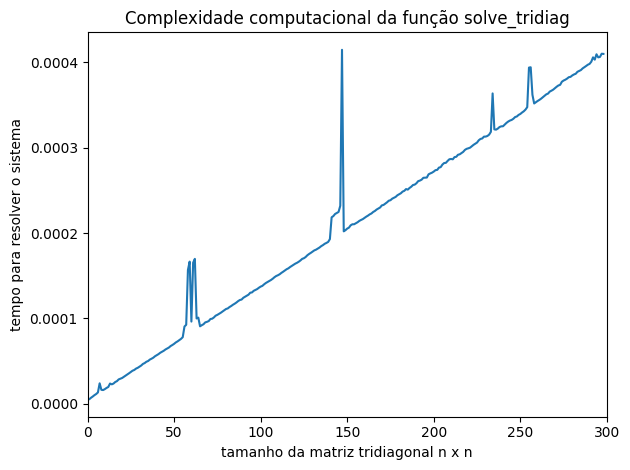

In [49]:
# plotar resultado
plt.plot(tempos_solve_tridiag)
plt.xlim(0,300)
plt.xlabel("tamanho da matriz tridiagonal n x n")
plt.ylabel("tempo para resolver o sistema")
plt.title("Complexidade computacional da função solve_tridiag")
plt.tight_layout()
plt.show

A partir do grafico acima podemos confirmar que a complexidade é O(n), temos ainda algumas flutuações (ruido) no tempo devido a subprocessos que o sistema faz no processo da medição do tempo

### Questão 2.4
A partir de que tamanho de matriz $A$ a função `solve_tridiag` se torna mais rápida do que a função `numpy.linalg.solve` (ou `\`, em Julia)?
Como você fez para chegar neste resultado?

In [45]:
tempos_np_linalg_solve = []

np.random.seed(0)
for n in range(2, 300):
    A = gerar_tridiagonal(n)
    b = gerar_b(n)

    # Calentamento
    np.linalg.solve(A, b)
    np.linalg.solve(A, b)
    
    tempo = medir_tempo(np.linalg.solve, A, b, repeat=100)

    tempos_np_linalg_solve.append(tempo)

<function matplotlib.pyplot.show(close=None, block=None)>

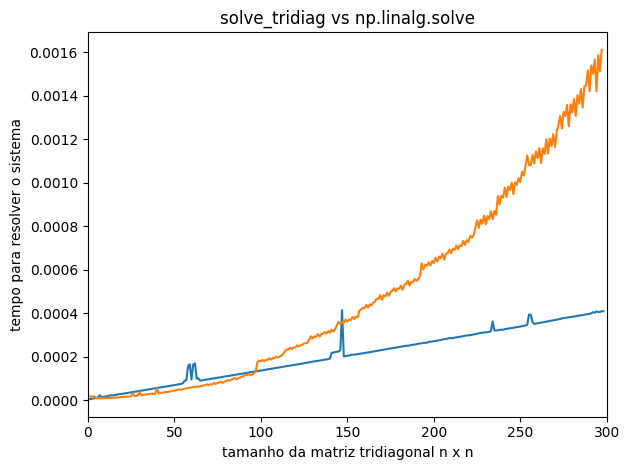

In [50]:
# plotar resultado
plt.plot(tempos_solve_tridiag, label="solve_tridiag")
plt.plot(tempos_np_linalg_solve, label="np.linalg.solve")
plt.xlim(0,300)
plt.xlabel("tamanho da matriz tridiagonal n x n")
plt.ylabel("tempo para resolver o sistema")
plt.title("solve_tridiag vs np.linalg.solve")
plt.tight_layout()
plt.show

A partir do tamanho $100 \times 100$ aproximadamente. O resultado foi obtido inspecionando o grafico acima.